# Indiana Bosonic Code - DMANH

In [1]:
from jaqalpaq import run
from jaqalpaq import emulator
from jaqalpaq.run import run_jaqal_file, run_jaqal_string, run_jaqal_batch, run_jaqal_circuit, frontend

from jaqalpaq.emulator.unitary import UnitarySerializedEmulator
emulator_backend = UnitarySerializedEmulator()

#from Experiment import Experiment
import numpy as np
import csv
from datetime import datetime, date, time, timezone
from pytz import timezone
from collections import OrderedDict
import pytz
from scipy.special import jn_zeros
import math
import matplotlib.pyplot as plt
import pickle as pkl
from jaqalpaq.parser import parse_jaqal_string
from pprint import pprint

def timestamp_generate():
    mountain = timezone('US/Mountain')
    timestamp_utc = datetime.utcnow()
    timestamp_local = timestamp_utc.astimezone(mountain)
    return(timestamp_utc, timestamp_local)

def int_to_base(n, b):
    if n == 0:
        return "0"
    digits = []
    is_negative = n < 0
    n = abs(n)
    while n:
        digits.append(int(n % b))
        n //= b
    if is_negative:
        digits.append("-")
    return ''.join(str(x) if x < 10 else chr(55 + x) for x in reversed(digits))



In [2]:
#Can import a file here with the angles in it, so angles can be called automatically. 

nq = 2
repeats = 1000
im_beta_list = np.linspace(-0.4, 0.4, 5).tolist()
override_dict = {"__repeats__": repeats,
                 "imBeta": im_beta_list}


import os
import ast

working_dir = os.getcwd()
recursive_dir = working_dir
for ii in range(5):
    temp_dir = os.path.dirname(recursive_dir)
    recursive_dir = temp_dir
file_path = recursive_dir


#with open(os.path.join(file_path,'Indiana_QSD_Dict1.txt'), 'r') as file:
#    string_data = file.read()
#angles = ast.literal_eval(string_data)

# ok, making this part up now as it doesn't exist, so how 
# exactly this is called in should be modified to match the actual file
angle = [[-0.18512000000000001, 0, -0.79999999999999982],
        [-0.18128949140032261, -0.03746377861097782, -0.79999999999999982],
        [-0.16995648759926149, -0.073377153957632377, -0.79999999999999982]]

def generate_jaqal_header():
    header = '''from Calibration_PulseDefinitions.QubitBosonPulses usepulses *

let reBeta -0.20000000000000001
let imBeta 0
let imMeas 1

register q[2]
'''
    return header # .replace("from Calibration_PulseDefinitions.QubitBosonPulses usepulses *", "from qscout.v1.std usepulses *")

def generate_jaqal_code(timesteps):
    circuit = ''
    for max in range(timesteps): 
        circuit += 'prepare_all\n'
        circuit += '// Timestep %s \n' %(max)
        for time in range(max+1):
            circuit += '// Circuit %s \n' %(time)
            circuit += 'xCD q[0] 1 1 %s %s \n' %(angle[time][0], angle[time][1])
            circuit += 'Rz q[0] %s \n' % (angle[time][2])
            circuit += 'xCD q[0] 1 1 %s %s \n' %(-angle[time][0], -angle[time][1])
            circuit += 'xCD q[0] 1 1 %s %s \n' %(-angle[time][0], -angle[time][1])
            circuit += 'Rz q[0] %s \n' % (angle[time][2])
            circuit += 'xCD q[0] 1 1 %s %s \n' %(angle[time][0], angle[time][1])
        circuit += "// Characteristic-function readout.\n"
        circuit += "loop imMeas {\n"
        circuit += "R q[1] 0 1.5707963267948966\n"
        circuit += "}\n"
        circuit += f"xCD q[1] 1 1 reBeta imBeta\n"
        circuit += "measure_all\n"
    return circuit


In [3]:
# List is removed because batching has been moved to overrides

#Make the jaqal files looping over the betas such that each one is a different "batch" 

# circuit_list=[] # list of circuits for the subset, divided into batches
header = generate_jaqal_header()
circuits = generate_jaqal_code(len(angle)) 
jaqal_string = header + circuits 

print(jaqal_string)

from Calibration_PulseDefinitions.QubitBosonPulses usepulses *

let reBeta -0.20000000000000001
let imBeta 0
let imMeas 1

register q[2]
prepare_all
// Timestep 0 
// Circuit 0 
xCD q[0] 1 1 -0.18512 0 
Rz q[0] -0.7999999999999998 
xCD q[0] 1 1 0.18512 0 
xCD q[0] 1 1 0.18512 0 
Rz q[0] -0.7999999999999998 
xCD q[0] 1 1 -0.18512 0 
// Characteristic-function readout.
loop imMeas {
R q[1] 0 1.5707963267948966
}
xCD q[1] 1 1 reBeta imBeta
measure_all
prepare_all
// Timestep 1 
// Circuit 0 
xCD q[0] 1 1 -0.18512 0 
Rz q[0] -0.7999999999999998 
xCD q[0] 1 1 0.18512 0 
xCD q[0] 1 1 0.18512 0 
Rz q[0] -0.7999999999999998 
xCD q[0] 1 1 -0.18512 0 
// Circuit 1 
xCD q[0] 1 1 -0.1812894914003226 -0.03746377861097782 
Rz q[0] -0.7999999999999998 
xCD q[0] 1 1 0.1812894914003226 0.03746377861097782 
xCD q[0] 1 1 0.1812894914003226 0.03746377861097782 
Rz q[0] -0.7999999999999998 
xCD q[0] 1 1 -0.1812894914003226 -0.03746377861097782 
// Characteristic-function readout.
loop imMeas {
R q[1] 0 1.5

In [4]:
#This will not run on the emulator, so leaving that if statement out. 

# result = run.run_jaqal_string(circuit_list, overrides = override_dict)
results = run.run_jaqal_string(jaqal_string, overrides = override_dict)

# print(results)

In [5]:
def exp_z(prob): #Postselect the results on the 
    #probe qubit's state probabilities
    if prob[0] + prob[2] == 0:
        state0 = 0
        state1 = 0
    else:
        state0 = prob[0]/(prob[0]+prob[2])
        state1 = prob[2]/(prob[0]+prob[2])
    
    return state0 - state1

In [6]:
#Extract the data from the results object
#This extracts the axis data



imMeas = np.empty((len(im_beta_list), len(angle), nq ** 2))
expZ_imMeas = np.empty((len(im_beta_list), len(angle)))

print(len(results.by_subbatch[0].by_subcircuit[0].probability_by_int[:,0]))

for ii in range(len(im_beta_list)):
    for jj in range(len(angle)):
        imMeas[ii, jj, :] = results.by_subbatch[ii].by_subcircuit[jj].probability_by_int[:,0]
        expZ_imMeas[ii, jj] = exp_z(imMeas[ii, jj])
print(imMeas[0, 0])
print(expZ_imMeas)
np.save('expZ_imMeas',expZ_imMeas) 


# #Save all probabilities
# np.save('prob_reMeas',reMeas)
# np.save('prob_imMeas',imMeas)

# #Save beta ranges
# np.save('ReBetas',re_values)
# np.save('ImBetas',im_values)

# #Save blue sideband data
# np.save('bsb_probs',bsb_results)
# np.save('bsb_angles',angles)

4
[0.503 0.031 0.426 0.04 ]
[[ 0.08288482 -0.03542857 -0.02521008]
 [ 0.49561404  0.26473988 -0.00347625]
 [ 0.98938429  1.          0.99761051]
 [ 0.50110375  0.2972973  -0.02352941]
 [ 0.05454545 -0.00938967 -0.05522914]]


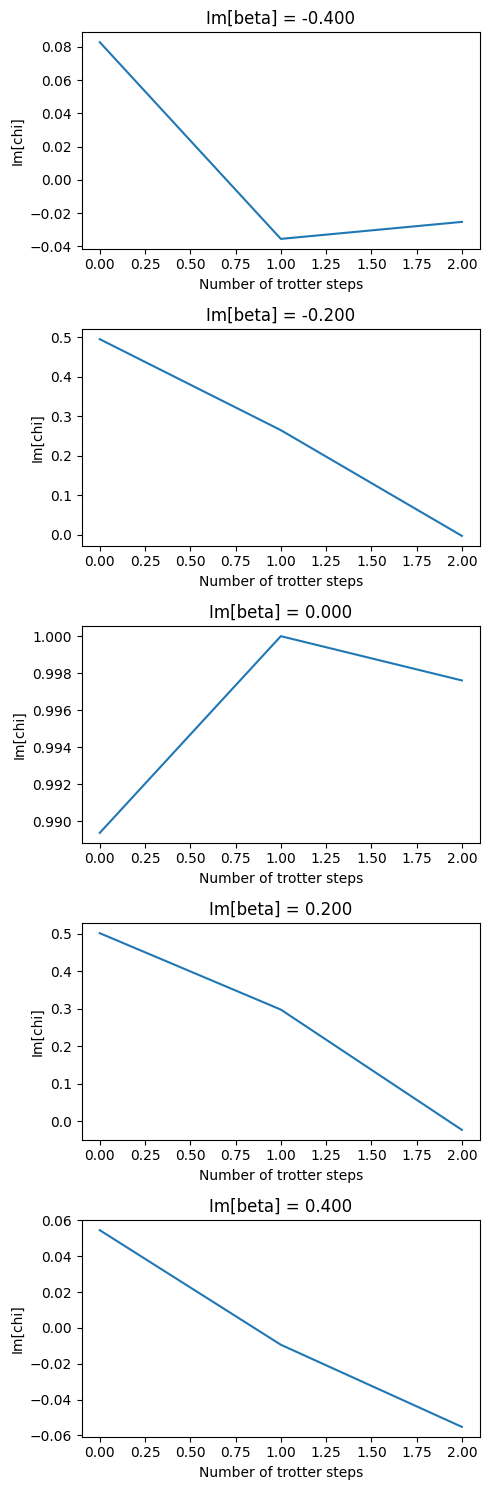

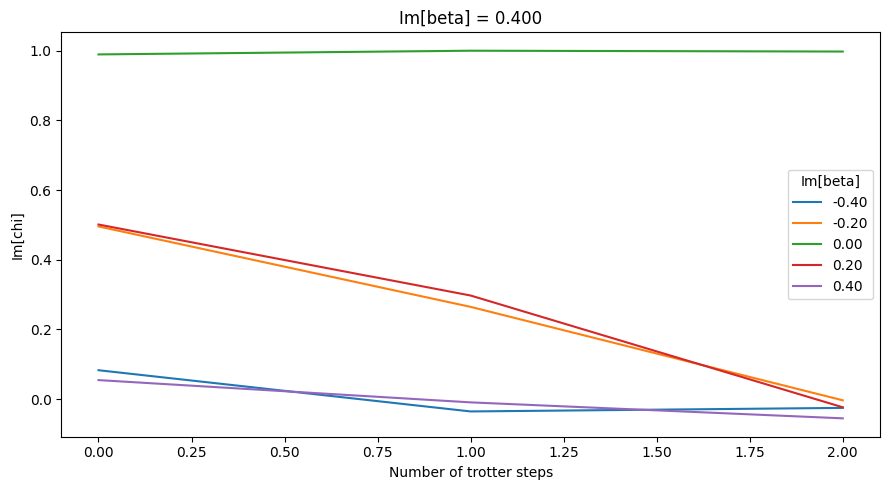

In [7]:
fig, axes = plt.subplots(5, 1, figsize=(5, len(angle)*5))

for ii, beta in enumerate(im_beta_list):
    axes[ii].plot(np.arange(len(angle)), expZ_imMeas[ii, :], label=f"{beta:.2f}")
    axes[ii].set_title(f"Im[beta] = {beta:.3f}")
    axes[ii].set_xlabel("Number of trotter steps")
    axes[ii].set_ylabel("Im[chi]")
fig.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
for  ii, beta in enumerate(im_beta_list):
    ax.plot(np.arange(len(angle)), expZ_imMeas[ii, :], label=f"{beta:.2f}")
ax.set_title(f"Im[beta] = {beta:.3f}")
ax.set_xlabel("Number of trotter steps")
ax.set_ylabel("Im[chi]")
ax.legend(title="Im[beta]")
fig.tight_layout()